
# Visualize First 10 GNSS Spectrograms from `train.txt`

In [1]:

# --- Configuration ---
TRAIN_TXT = "../fiot_highway2-main/train.txt"   # e.g., "/path/to/dataset/train.txt"
DATA_ROOT = "../fiot_highway2-main"                   # e.g., "/path/to/dataset"
FS = 62_500_000.0                 # sample rate in Hz; Spectrum Highway uses 62.5 MHz
NFFT = 1024                       # FFT size for spectrogram
HOP = 256                         # Hop size (overlap = NFFT - HOP)
WIN = "hann"                      # 'hann', 'hamming', or 'boxcar'
VMIN_DB = None                    # e.g., -120
VMAX_DB = None                    # e.g., -40
MAX_ITEMS = 10                    # visualize the first N entries in train.txt


In [2]:

import os
import numpy as np
import matplotlib.pyplot as plt

from typing import Tuple

%matplotlib inline


In [3]:

def load_iq(path: str) -> np.ndarray:
    """
    Load IQ from .npy with common layouts:
      - complex dtype: shape (N,)
      - real 2-col: shape (N,2) -> I + jQ
      - interleaved 1D real: shape (2N,) -> I,Q,I,Q,...
    Returns complex64 array shape (N,).
    """
    arr = np.load(path, allow_pickle=False)
    if np.iscomplexobj(arr):
        return np.asarray(arr).astype(np.complex64)
    if arr.ndim == 2 and arr.shape[-1] == 2:
        I = arr[..., 0].astype(np.float32)
        Q = arr[..., 1].astype(np.float32)
        return I + 1j * Q
    if arr.ndim == 1 and (arr.size % 2 == 0):
        I = arr[0::2].astype(np.float32)
        Q = arr[1::2].astype(np.float32)
        return I + 1j * Q
    flat = arr.ravel()
    if flat.size % 2 == 0:
        I = flat[0::2].astype(np.float32)
        Q = flat[1::2].astype(np.float32)
        return I + 1j * Q
    raise ValueError(f"Unrecognized IQ layout for file: {path} with shape {arr.shape} dtype {arr.dtype}")


def window_fn(name: str, N: int) -> np.ndarray:
    name = name.lower()
    if name == "hann":
        return np.hanning(N).astype(np.float32)
    if name == "hamming":
        return np.hamming(N).astype(np.float32)
    if name == "boxcar":
        return np.ones(N, dtype=np.float32)
    raise ValueError(f"Unsupported window type: {name}")


def stft_mag_db(xc: np.ndarray, nfft: int = 1024, hop: int = 256, win: str = "hann", eps: float = 1e-10) -> np.ndarray:
    """
    Compute STFT magnitude in dB for a complex baseband signal.
    Returns S_db with shape (freq_bins, frames).
    """
    x = np.asarray(xc, dtype=np.complex64)
    w = window_fn(win, nfft)
    if len(x) < nfft:
        x = np.pad(x, (0, nfft - len(x)))
    n_frames = 1 + max(0, (len(x) - nfft) // hop)
    frames = np.lib.stride_tricks.as_strided(
        x,
        shape=(n_frames, nfft),
        strides=(x.strides[0]*hop, x.strides[0]),
        writeable=False
    )
    frames = frames * w[None, :]
    X = np.fft.fftshift(np.fft.fft(frames, n=nfft, axis=1), axes=1)
    S = np.abs(X)**2
    S_db = 10.0 * np.log10(S + eps).T  # (freq_bins, frames)
    return S_db


def spectrogram_image(iq: np.ndarray, fs: float, nfft: int, hop: int, win: str, vmin_db=None, vmax_db=None, ax=None):
    S_db = stft_mag_db(iq, nfft=nfft, hop=hop, win=win)
    freqs = np.linspace(-fs/2, fs/2, S_db.shape[0], endpoint=False)
    times = np.arange(S_db.shape[1]) * (hop / fs)
    if ax is None:
        ax = plt.gca()
    im = ax.imshow(
        S_db,
        origin="lower",
        aspect="auto",
        extent=[times[0], times[-1] if len(times)>1 else (len(times)/fs), freqs[0]/1e6, freqs[-1]/1e6],
        vmin=vmin_db,
        vmax=vmax_db,
        cmap="viridis",
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Freq (MHz)")
    return im


def read_train_list(train_txt: str, max_items: int = 10):
    entries = []
    with open(train_txt, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            relpath, label = parts[0], parts[1]
            label = int(str(label).strip().replace(",", ""))
            entries.append((relpath, label))
            if len(entries) >= max_items:
                break
    return entries


/tmp/ipykernel_402/1256442388.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


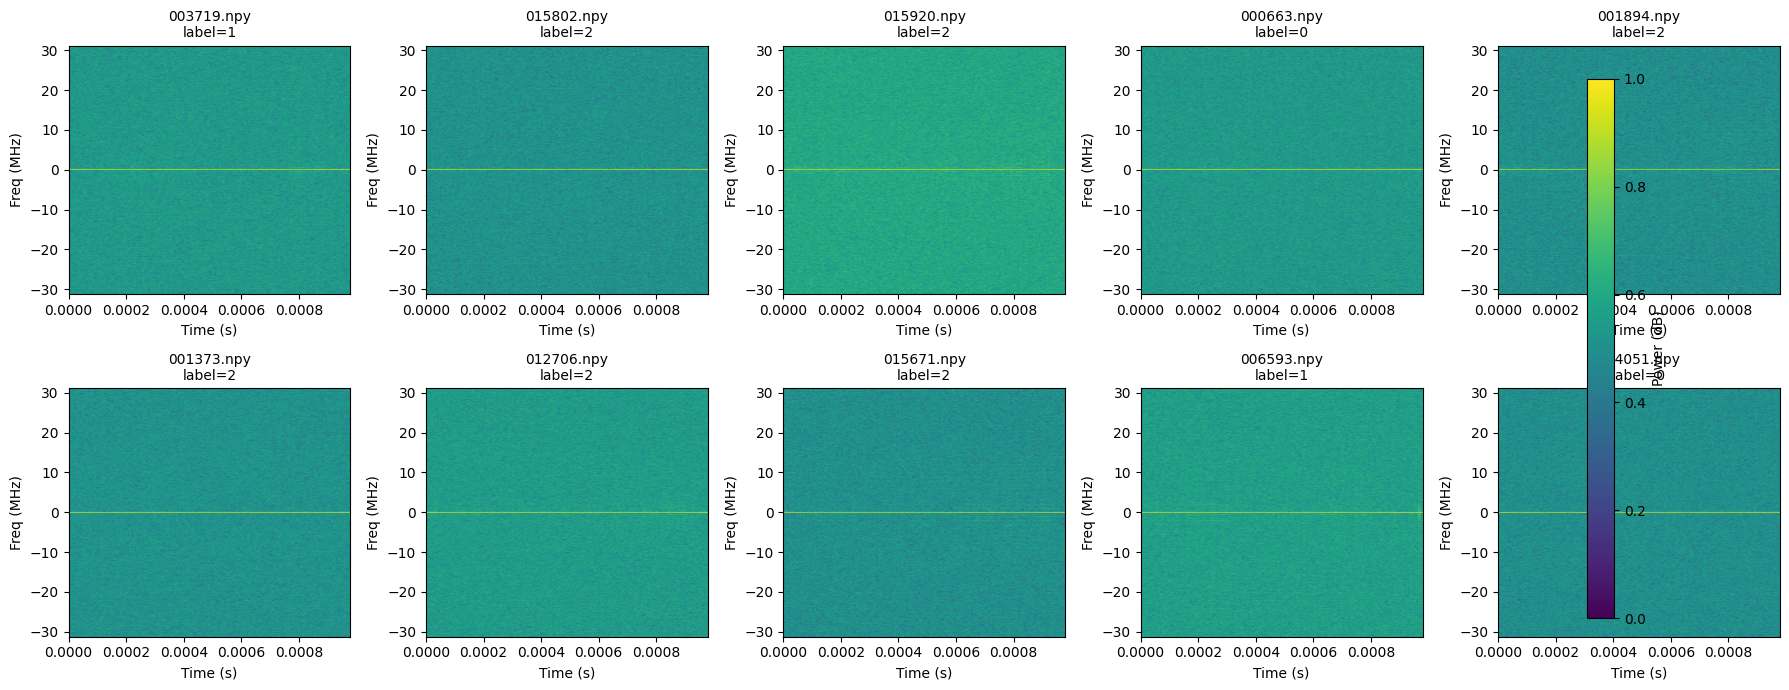

In [4]:

# --- Visualize the first 10 ---
entries = read_train_list(TRAIN_TXT, max_items=MAX_ITEMS)
if not entries:
    raise SystemExit("No entries found. Check TRAIN_TXT path.")

nrows, ncols = 2, 5
fig = plt.figure(figsize=(18, 7))
mappables = []

for i, (relpath, label) in enumerate(entries):
    fullpath = os.path.join(DATA_ROOT, relpath)
    ax = plt.subplot(nrows, ncols, i + 1)
    try:
        iq = load_iq(fullpath)
        im = spectrogram_image(
            iq,
            fs=FS,
            nfft=NFFT,
            hop=HOP,
            win=WIN,
            vmin_db=VMIN_DB,
            vmax_db=VMAX_DB,
            ax=ax,
        )
        mappables.append(im)
        ax.set_title(f"{os.path.basename(relpath)}\nlabel={label}", fontsize=10)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{e}", ha="center", va="center", wrap=True)
        ax.set_axis_off()

# Add a single colorbar
if mappables:
    from matplotlib.cm import ScalarMappable
    sm = ScalarMappable(cmap="viridis")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=fig.axes, fraction=0.02, pad=0.02)
    cbar.set_label("Power (dB)")

fig.tight_layout()
plt.show()


In [5]:

# --- Optional: Save the grid to disk ---
out_path = "spectrogram_grid.png"
fig = plt.gcf()
fig.savefig(out_path, dpi=200)
print(f"Saved grid to {out_path}")


Saved grid to spectrogram_grid.png


<Figure size 640x480 with 0 Axes>